# VortexLatticeViscous Validation

This notebook compares `VortexLatticeViscous` against `VortexLatticeMethod` and `LiftingLine` on a generic tapered wing. It checks whole-aircraft coefficients, profile-drag buildup, and spanwise stall margins.

`VortexLatticeViscous` keeps the VLM lift distribution unchanged, reads the VLM sectional `cl`, and uses a NeuralFoil polar to look up profile `cd` at that same `cl`. It does not internally stall-limit the lift; instead, it reports `spanwise_clmax` so optimization problems can constrain `spanwise_cl <= spanwise_clmax`.

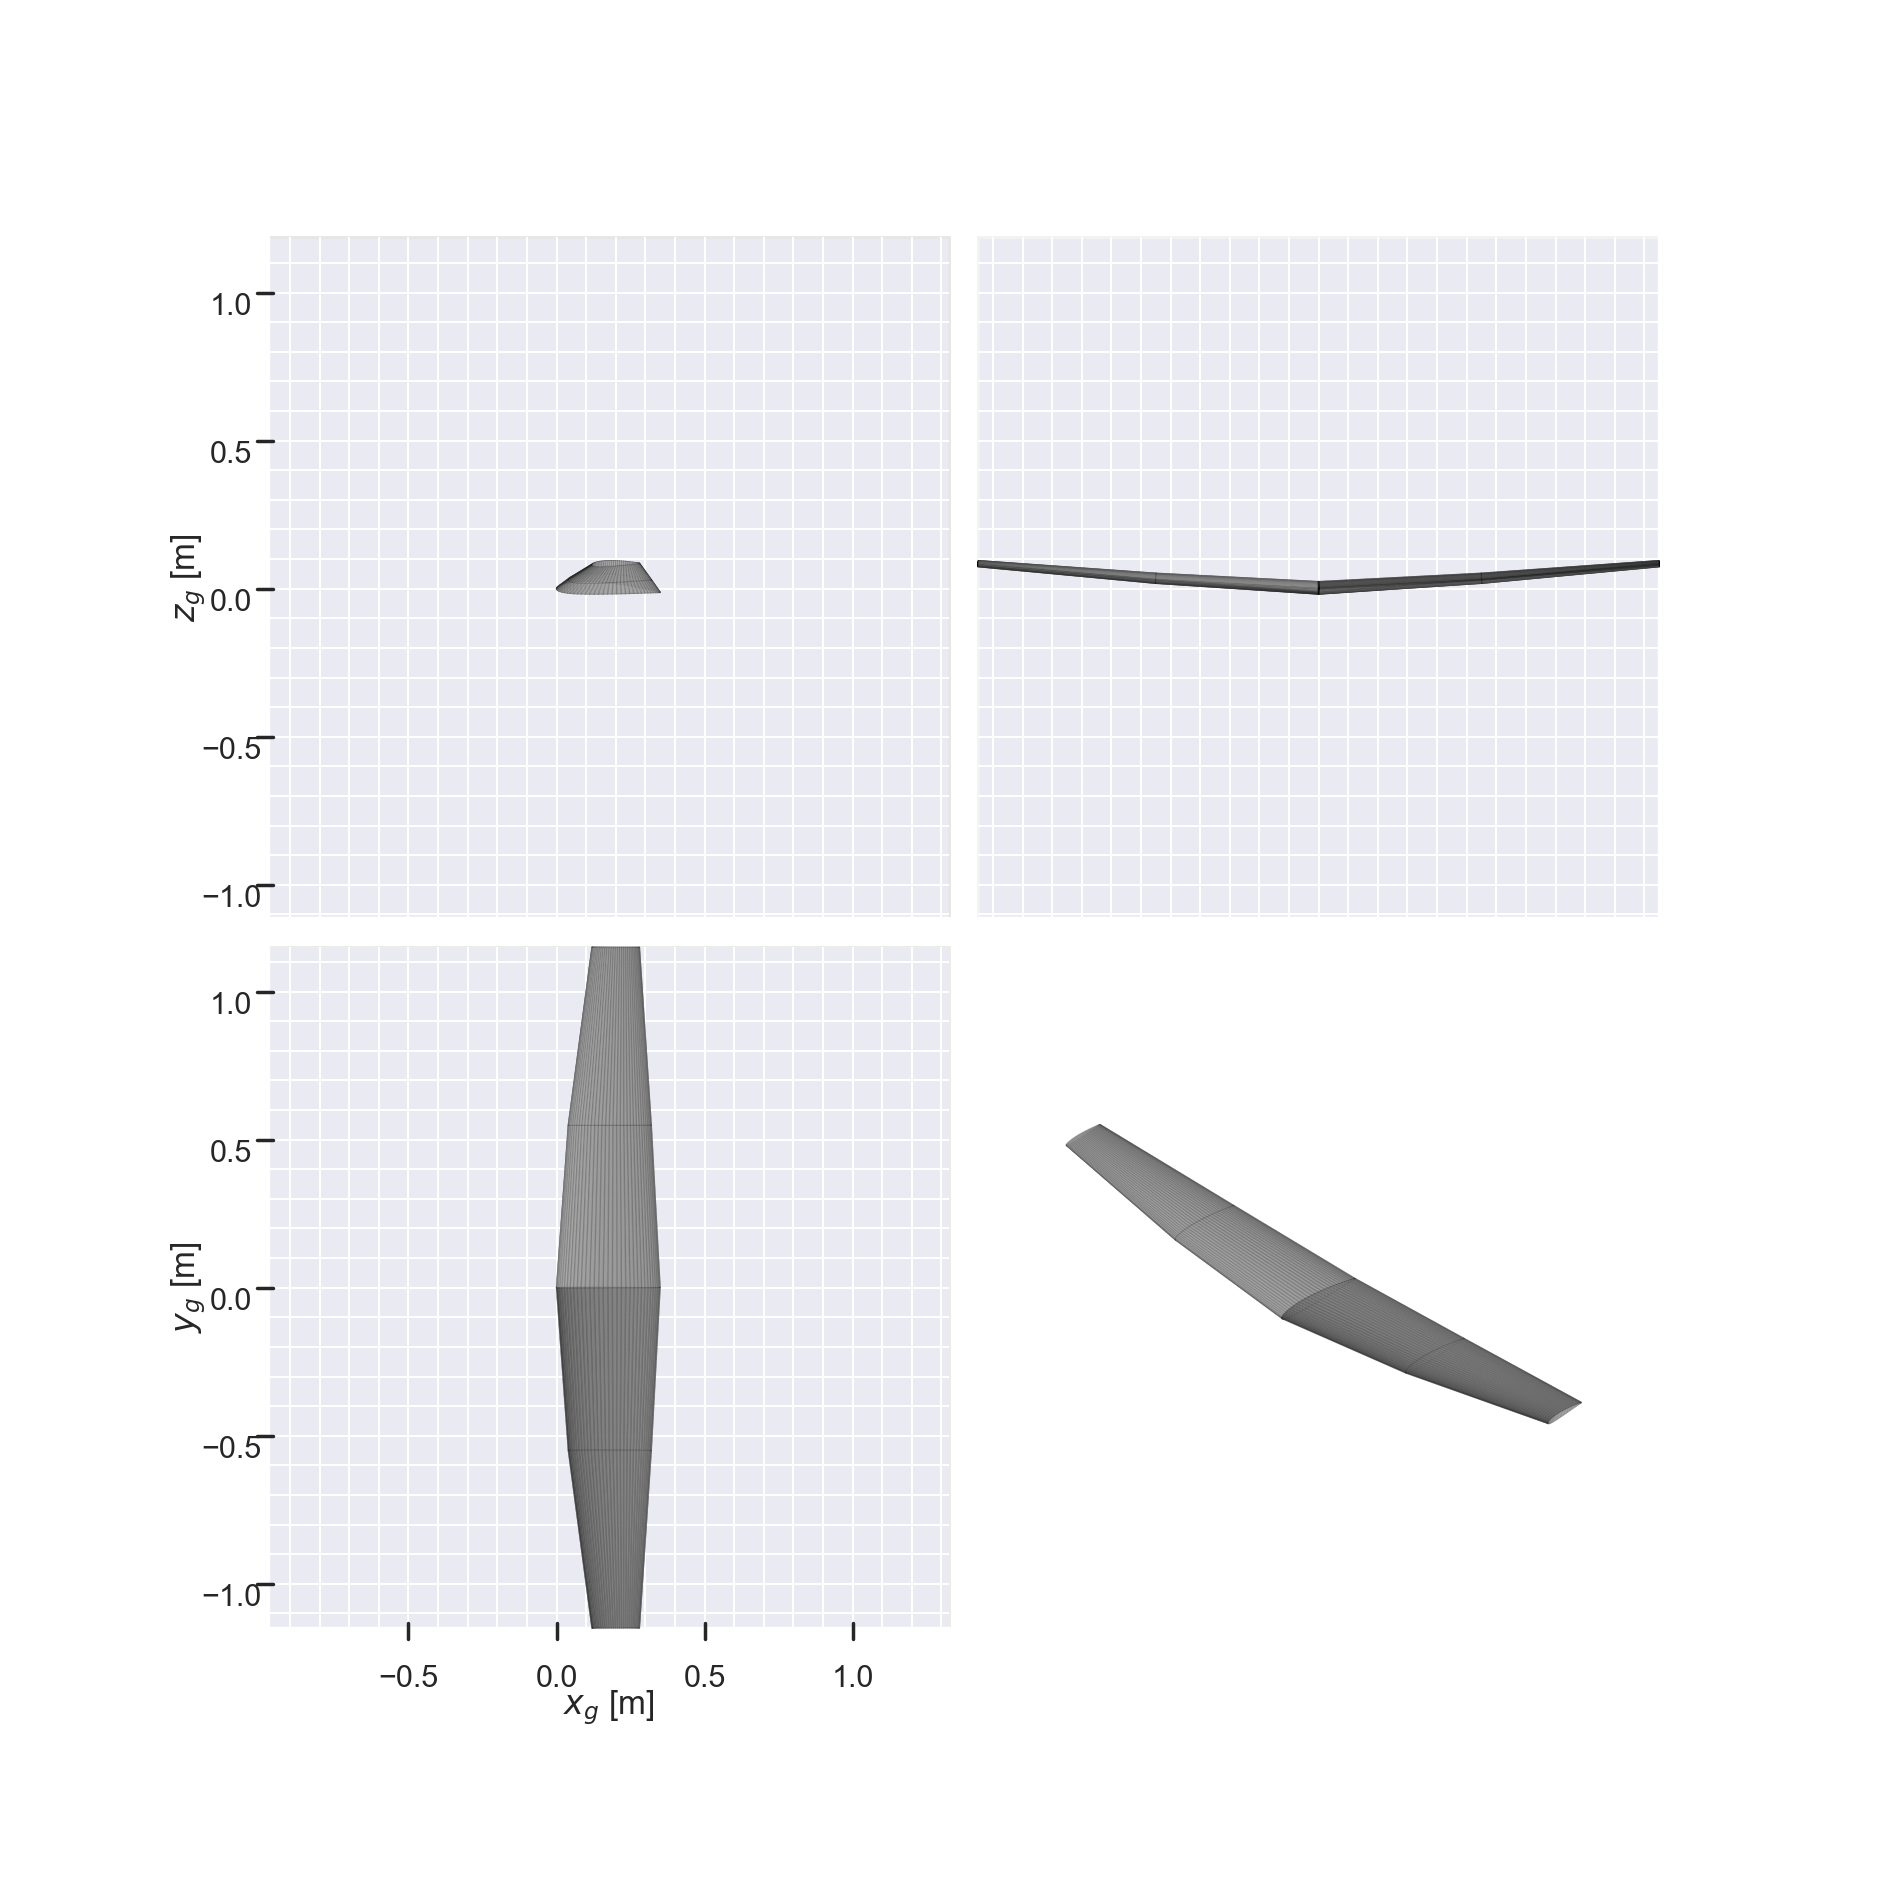

array([[<Axes3D: zlabel='$z_g$ [m]'>, <Axes3D: >],
       [<Axes3D: xlabel='$x_g$ [m]', ylabel='$y_g$ [m]'>, <Axes3D: >]],
      dtype=object)

In [1]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

velocity = 20
spanwise_resolution = 8
chordwise_resolution = 4
model_size = "xsmall"

wing_airplane = asb.Airplane(
    name="Generic Tapered Wing",
    xyz_ref=[0.25, 0, 0],
    wings=[
        asb.Wing(
            name="Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0, 0, 0],
                    chord=0.35,
                    twist=2,
                    airfoil=asb.Airfoil("naca2412"),
                ),
                asb.WingXSec(
                    xyz_le=[0.04, 0.55, 0.03],
                    chord=0.28,
                    twist=0,
                    airfoil=asb.Airfoil("naca2412"),
                ),
                asb.WingXSec(
                    xyz_le=[0.12, 1.15, 0.08],
                    chord=0.16,
                    twist=-2,
                    airfoil=asb.Airfoil("naca2412"),
                ),
            ],
        )
    ],
)

def run_methods(alpha):
    op_point = asb.OperatingPoint(velocity=velocity, alpha=alpha)
    return {
        "VLM": asb.VortexLatticeMethod(
            airplane=wing_airplane,
            op_point=op_point,
            spanwise_resolution=spanwise_resolution,
            chordwise_resolution=chordwise_resolution,
            align_trailing_vortices_with_wind=False,
        ).run(),
        "LLM": asb.LiftingLine(
            airplane=wing_airplane,
            op_point=op_point,
            spanwise_resolution=spanwise_resolution,
            model_size=model_size,
            align_trailing_vortices_with_wind=False,
        ).run(),
        "VLV": asb.VortexLatticeViscous(
            airplane=wing_airplane,
            op_point=op_point,
            spanwise_resolution=spanwise_resolution,
            chordwise_resolution=chordwise_resolution,
            model_size=model_size,
            align_trailing_vortices_with_wind=False,
        ).run(),
    }

def ordered_spanwise(result, key, wing_index=0):
    mask = result["spanwise_wing_index"] == wing_index
    y = result["spanwise_y"][mask]
    values = result[key][mask]
    order = np.argsort(y)
    return y[order], values[order]

wing_airplane.draw_three_view()

## Coefficient Sweep

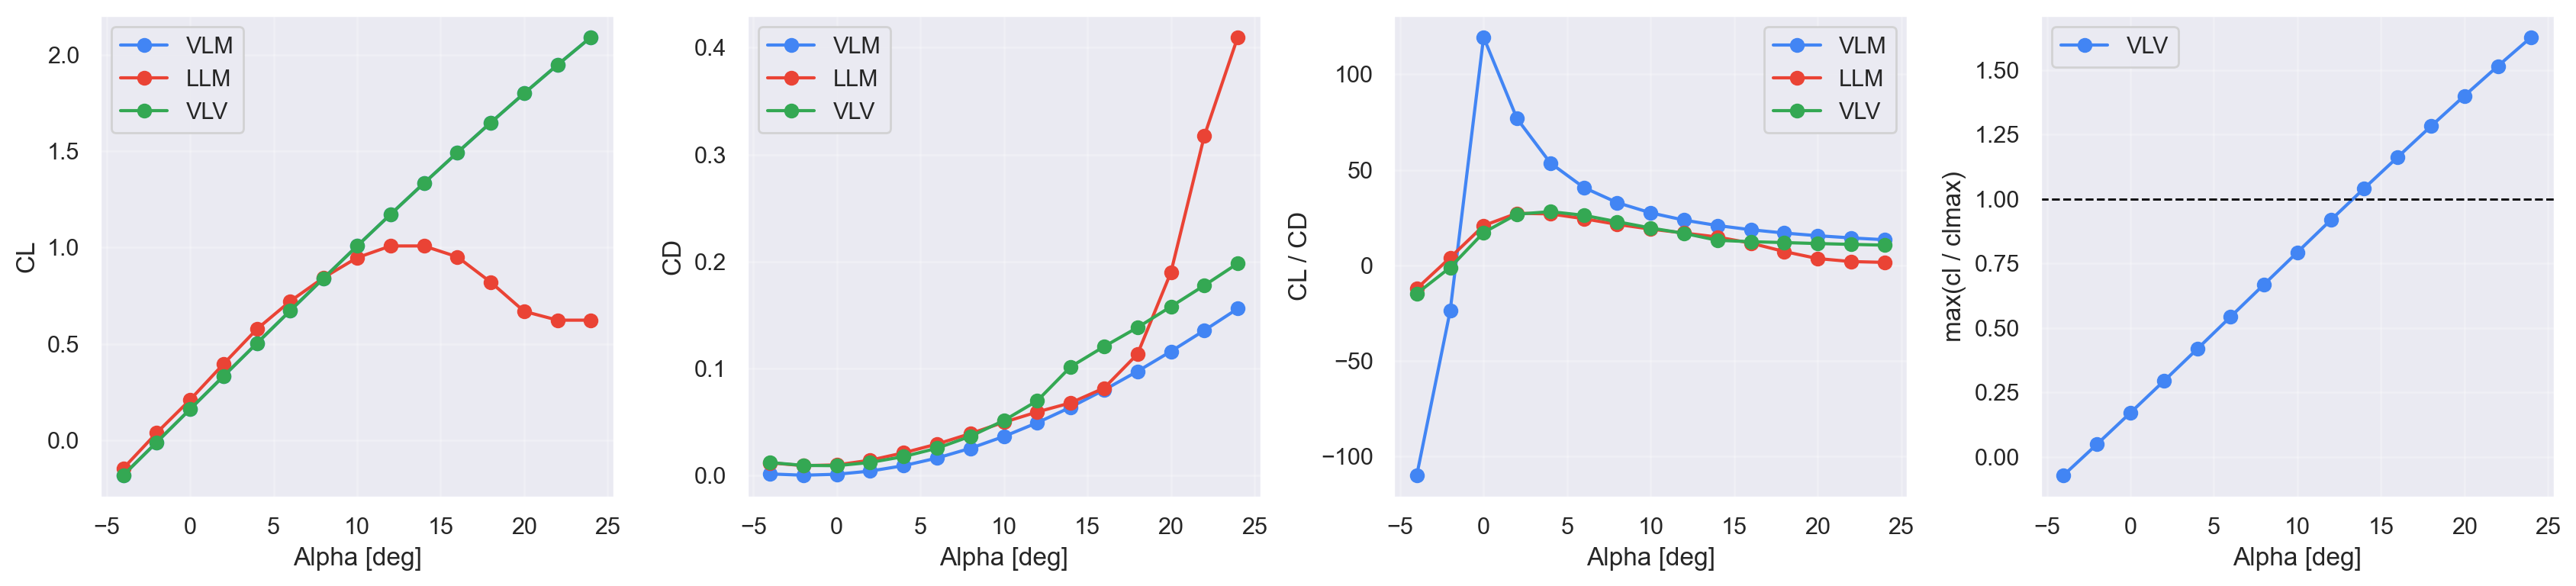

In [2]:
alphas = np.linspace(-4, 24, 15)
sweep = {
    name: {"CL": [], "CD": [], "LD": [], "max_cl_over_clmax": []}
    for name in ["VLM", "LLM", "VLV"]
}

for alpha in alphas:
    results = run_methods(alpha)
    for name, result in results.items():
        sweep[name]["CL"].append(result["CL"])
        sweep[name]["CD"].append(result["CD"])
        sweep[name]["LD"].append(result["CL"] / result["CD"])
        if name == "VLV":
            sweep[name]["max_cl_over_clmax"].append(
                np.max(result["spanwise_cl"] / result["spanwise_clmax"])
            )
        else:
            sweep[name]["max_cl_over_clmax"].append(np.nan)

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for name, data in sweep.items():
    axes[0].plot(alphas, data["CL"], marker="o", label=name)
    axes[1].plot(alphas, data["CD"], marker="o", label=name)
    axes[2].plot(alphas, data["LD"], marker="o", label=name)
    if name == "VLV":
        axes[3].plot(alphas, data["max_cl_over_clmax"], marker="o", label=name)

axes[0].set_ylabel("CL")
axes[1].set_ylabel("CD")
axes[2].set_ylabel("CL / CD")
axes[3].set_ylabel("max(cl / clmax)")
axes[3].axhline(1, color="black", linewidth=1, linestyle="--")
for ax in axes:
    ax.set_xlabel("Alpha [deg]")
    ax.grid(True, alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Attached-Flow Spanwise Distributions

Attached case, alpha = 5 deg
VLM: CL = 0.5873, CD = 0.0127, CL/CD = 46.3
LLM: CL = 0.6526, CD = 0.0253, CL/CD = 25.8
VLV: CL = 0.5873, CD = 0.0215, CL/CD = 27.4


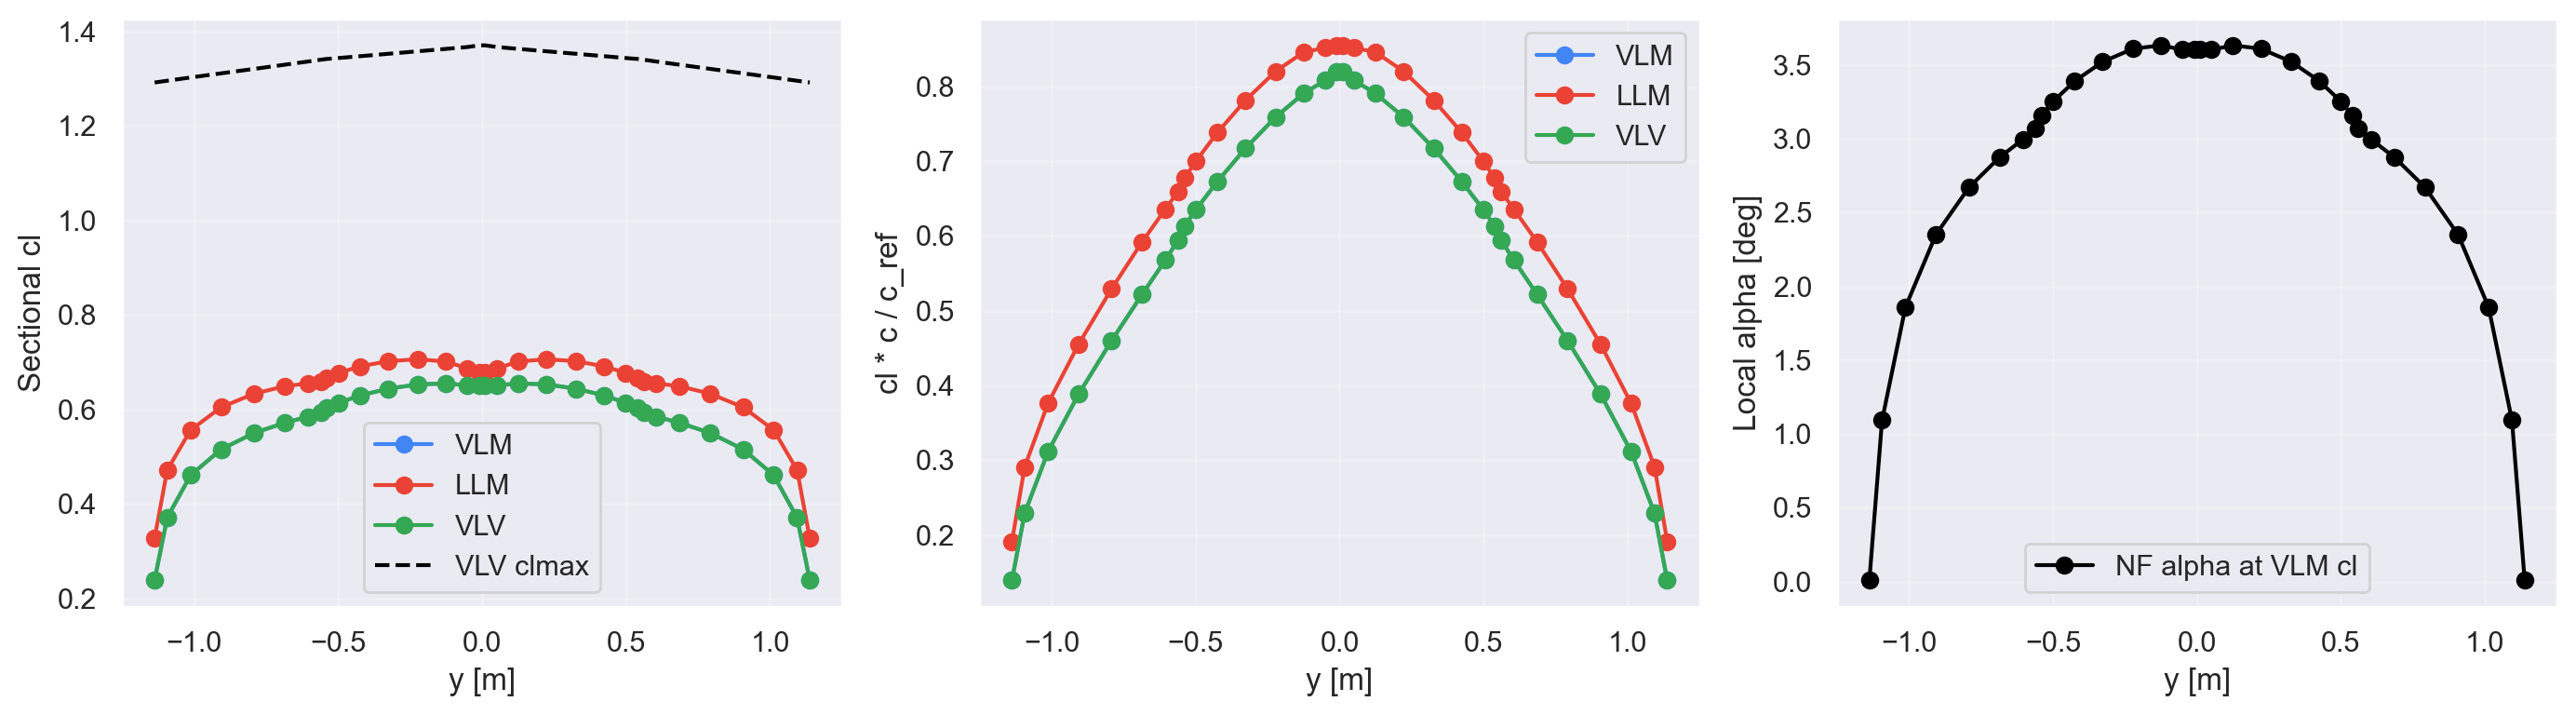

In [3]:
attached_alpha = 5
attached = run_methods(attached_alpha)

print(f"Attached case, alpha = {attached_alpha} deg")
for name, result in attached.items():
    print(f"{name:>3s}: CL = {result['CL']:.4f}, CD = {result['CD']:.4f}, CL/CD = {result['CL'] / result['CD']:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name, result in attached.items():
    axes[0].plot(result["y"][0], result["cl"][0], marker="o", label=name)
    axes[1].plot(result["y"][0], result["clc_over_cref"][0], marker="o", label=name)

y_clmax, spanwise_clmax = ordered_spanwise(attached["VLV"], "spanwise_clmax")
axes[0].plot(y_clmax, spanwise_clmax, color="black", linestyle="--", label="VLV clmax")

y_alpha, spanwise_alpha = ordered_spanwise(attached["VLV"], "spanwise_alpha")
axes[2].plot(y_alpha, spanwise_alpha, marker="o", color="black", label="NF alpha at VLM cl")

axes[0].set_ylabel("Sectional cl")
axes[1].set_ylabel("cl * c / c_ref")
axes[2].set_ylabel("Local alpha [deg]")
for ax in axes:
    ax.set_xlabel("y [m]")
    ax.grid(True, alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Near-Stall Spanwise Distributions

Near-stall case, alpha = 20 deg
VLM: CL = 1.7991, CD = 0.1162, CL/CD = 15.5
LLM: CL = 0.6681, CD = 0.1900, CL/CD = 3.5
VLV: CL = 1.7991, CD = 0.1580, CL/CD = 11.4
VLV max cl/clmax = 1.401


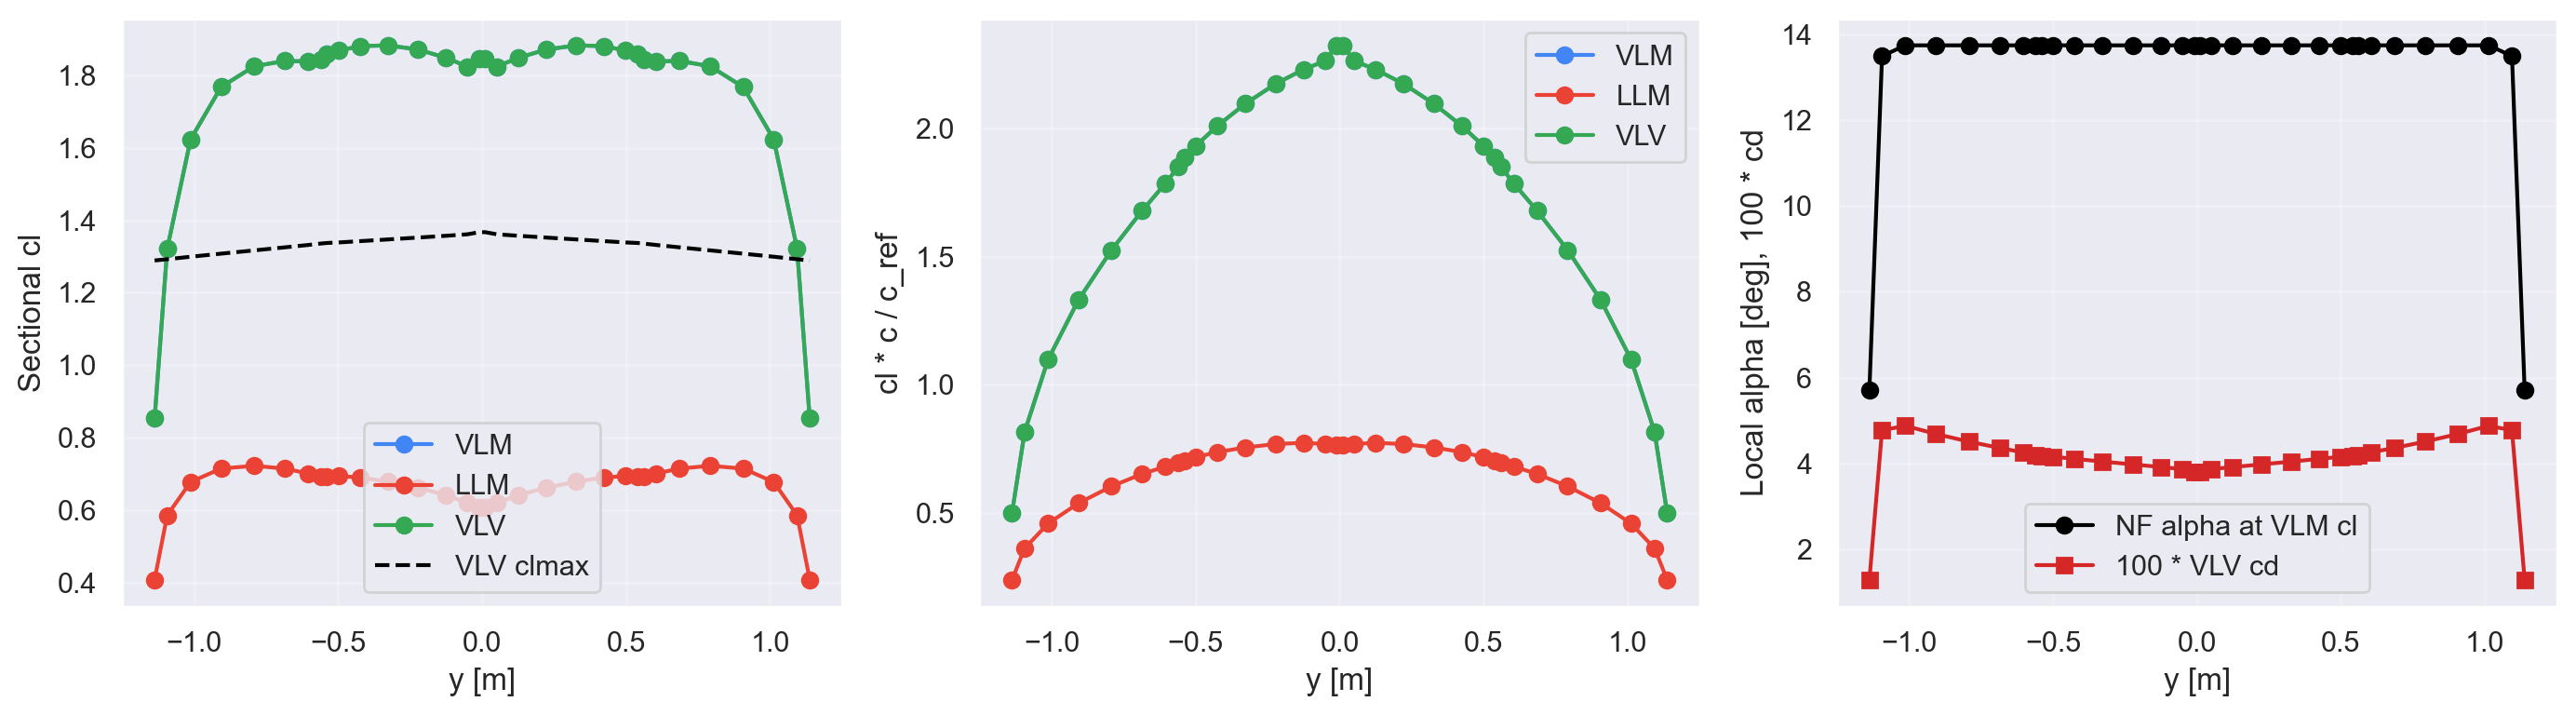

In [4]:
stall_alpha = 20
near_stall = run_methods(stall_alpha)

print(f"Near-stall case, alpha = {stall_alpha} deg")
for name, result in near_stall.items():
    print(f"{name:>3s}: CL = {result['CL']:.4f}, CD = {result['CD']:.4f}, CL/CD = {result['CL'] / result['CD']:.1f}")
print(f"VLV max cl/clmax = {np.max(near_stall['VLV']['spanwise_cl'] / near_stall['VLV']['spanwise_clmax']):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name, result in near_stall.items():
    axes[0].plot(result["y"][0], result["cl"][0], marker="o", label=name)
    axes[1].plot(result["y"][0], result["clc_over_cref"][0], marker="o", label=name)

y_clmax, spanwise_clmax = ordered_spanwise(near_stall["VLV"], "spanwise_clmax")
axes[0].plot(y_clmax, spanwise_clmax, color="black", linestyle="--", label="VLV clmax")

y_alpha, spanwise_alpha = ordered_spanwise(near_stall["VLV"], "spanwise_alpha")
y_cd, spanwise_cd = ordered_spanwise(near_stall["VLV"], "spanwise_cd_profile")
axes[2].plot(y_alpha, spanwise_alpha, marker="o", color="black", label="NF alpha at VLM cl")
axes[2].plot(y_cd, 100 * spanwise_cd, marker="s", color="tab:red", label="100 * VLV cd")

axes[0].set_ylabel("Sectional cl")
axes[1].set_ylabel("cl * c / c_ref")
axes[2].set_ylabel("Local alpha [deg], 100 * cd")
for ax in axes:
    ax.set_xlabel("y [m]")
    ax.grid(True, alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()